# Introduction
We may access a random element by index in Array. However, we might want to restrict the processing order in some cases.

In this card, we introduce two different processing orders, First-in-First-out and Last-in-First-out and its two corresponding linear data structures, Queue and Stack.

By completing this card, you should be able to:

1. Understand the principle of the processing orders of FIFO and LIFO;

2. Implement these two data structures;

3. Be familiar with the built-in queue and stack structure;

4. Solve basic queue-related problems, especially BFS;

5. Solve basic stack-related problems;

6. Understand how system stack helps you when you solve problems using DFS and other recursion algorithms;

# Queue

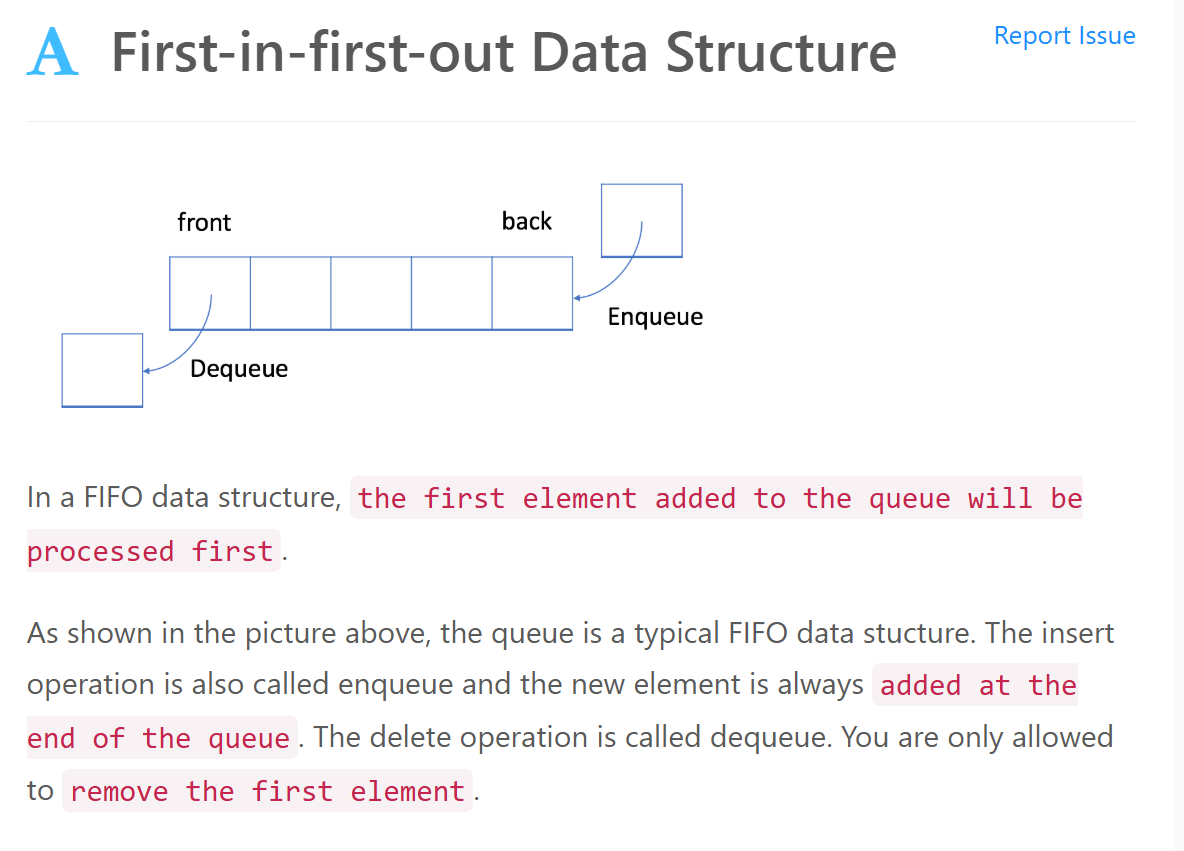

In [6]:
from collections import deque
from typing import Deque, List, Optional

class MyQueue:
    def __init__(self):
        self.data = deque()

    def enQueue(self, x: int) -> bool:
        self.data.append(x)
        return True

    def deQueue(self) -> bool:
        if self.isEmpty():
            return False
        self.data.popleft()
        return True

    def Front(self) -> int:
        return self.data[0]

    def isEmpty(self) -> bool:
        return len(self.data) == 0

# ===== Test (same as C++ main) =====
q = MyQueue()
q.enQueue(5)
q.enQueue(3)

if not q.isEmpty():
    print(q.Front())  # 5

q.deQueue()

if not q.isEmpty():
    print(q.Front())  # 3

q.deQueue()

if not q.isEmpty():
    print(q.Front())  # (won't print)

5
3


## Circular Queue

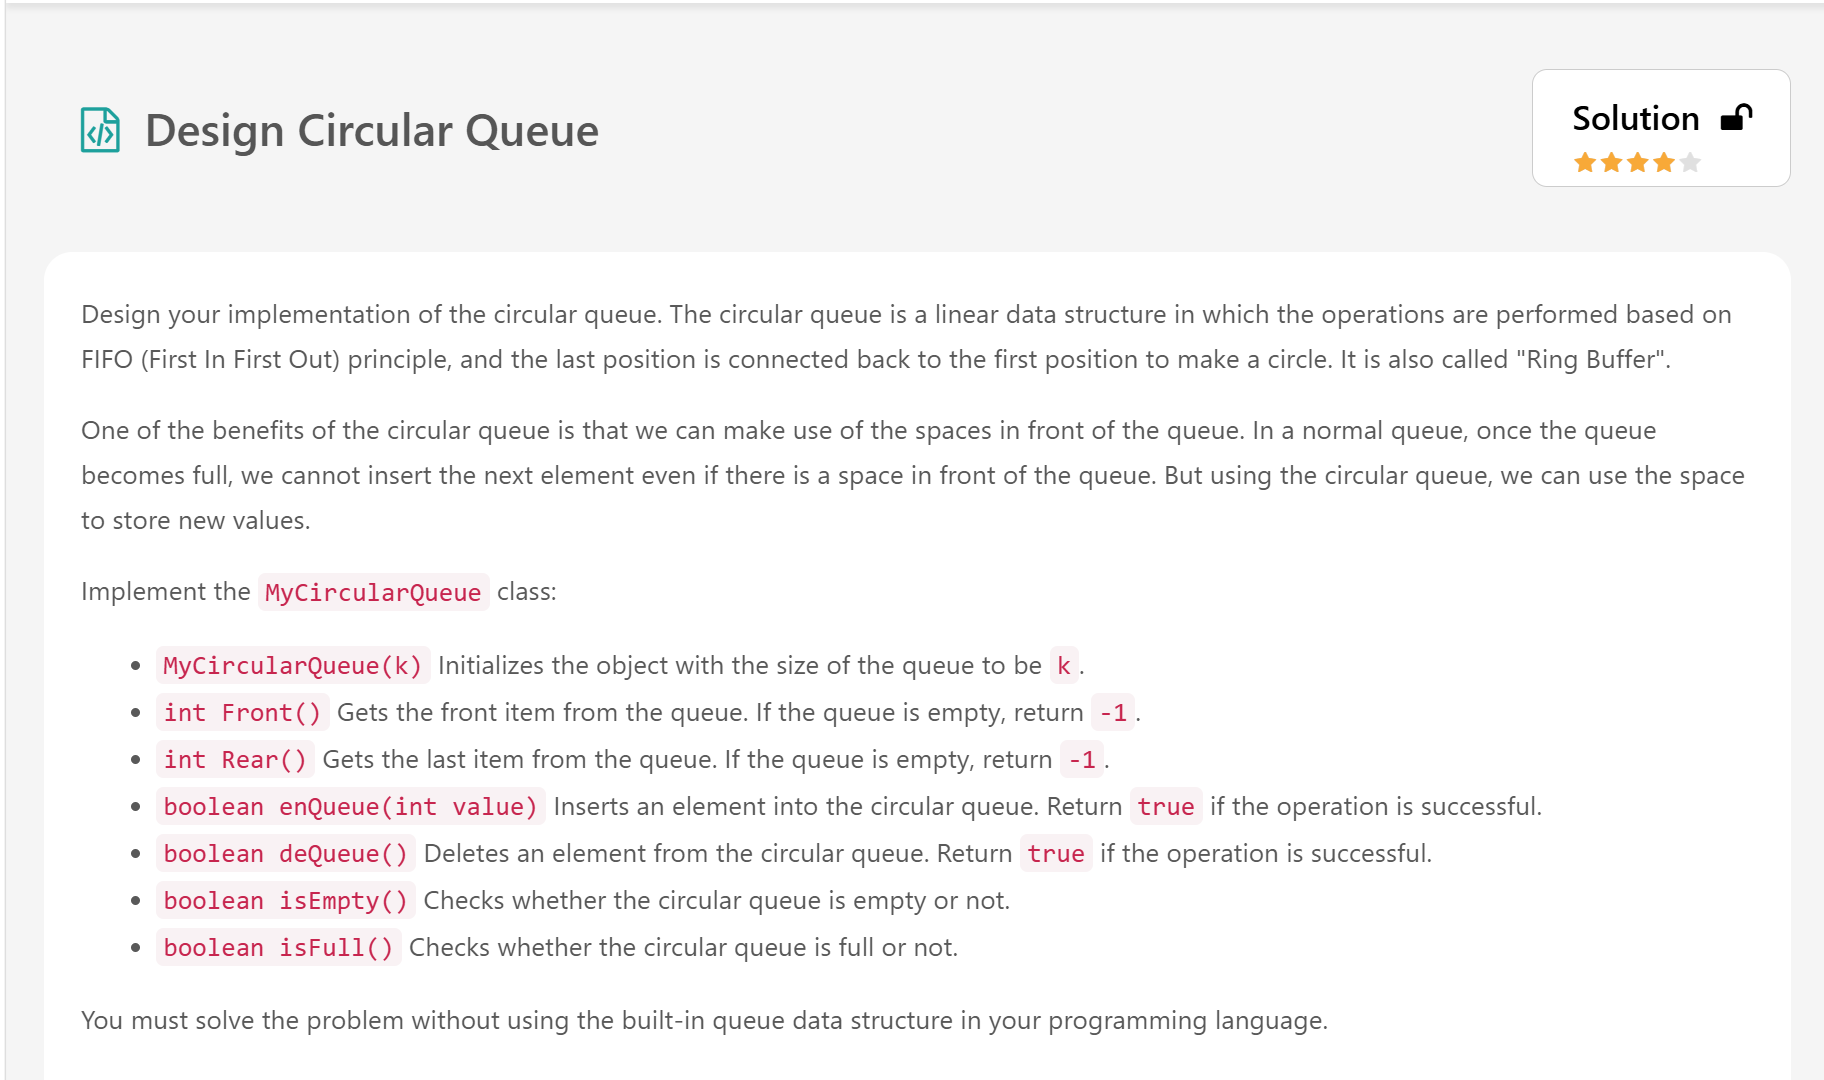

In [7]:
class MyCircularQueue:

    def __init__(self, k: int):
        self.k = k
        self.array = [0] * k
        self.size = 0
        self.head = 0
        self.tail = 0

    def enQueue(self, value: int) -> bool:
        if self.isFull():
            return False
        
        self.array[self.tail] = value
        self.tail = (self.tail + 1) % self.k
        self.size += 1
        return True

    def deQueue(self) -> bool:
        if self.isEmpty():
            return False
        
        self.head = (self.head + 1) % self.k
        self.size -= 1
        return True

    def Front(self) -> int:
        if self.isEmpty():
            return -1
        return self.array[self.head]

    def Rear(self) -> int:
        if self.isEmpty():
            return -1
        return self.array[(self.tail - 1 + self.k) % self.k]

    def isEmpty(self) -> bool:
        return self.size == 0

    def isFull(self) -> bool:
        return self.size == self.k

## Moving Average from Data Stream

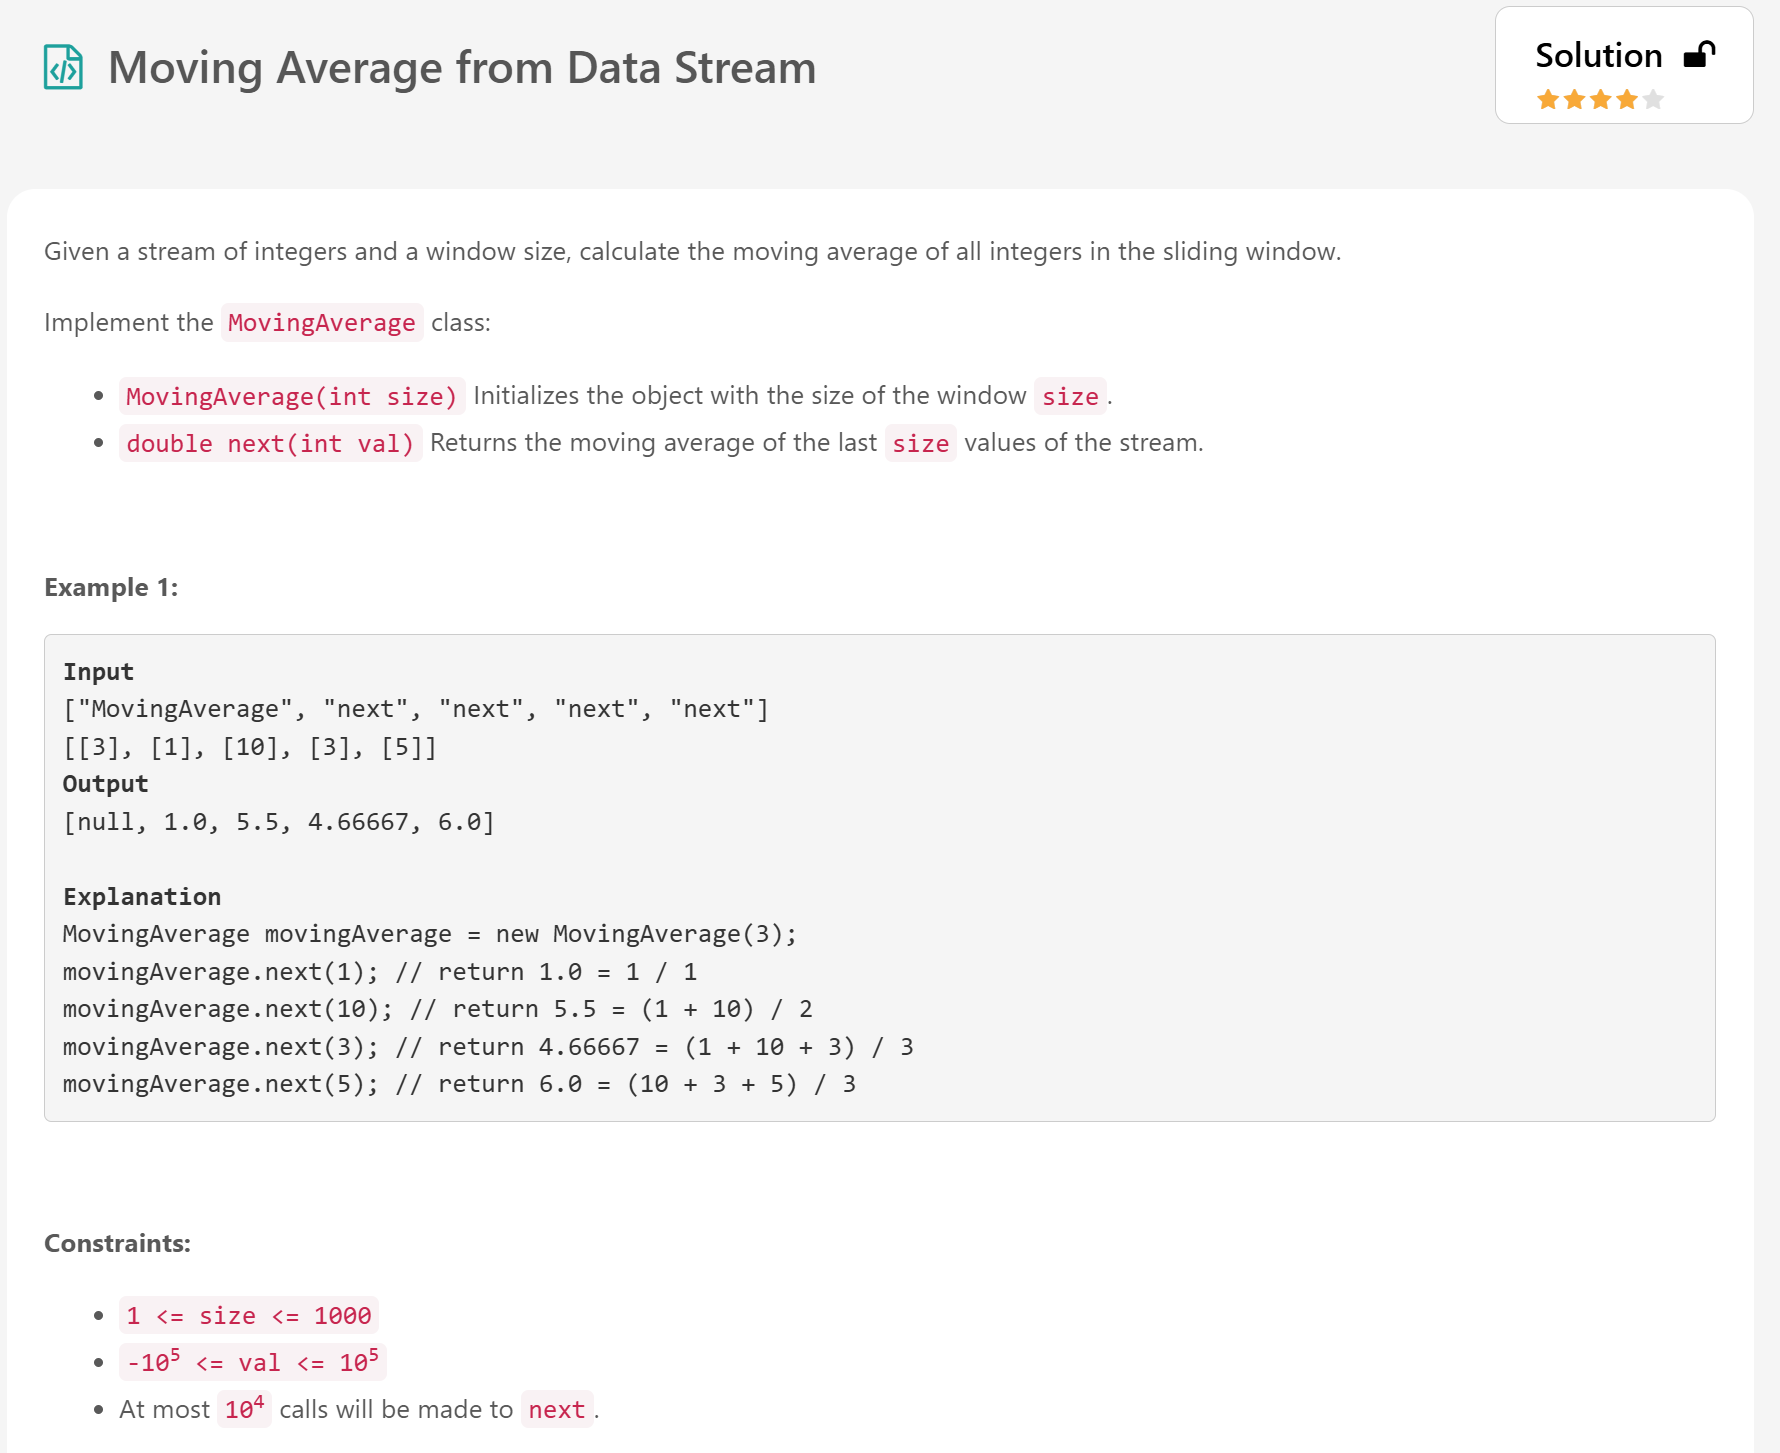

In [8]:
from collections import deque
class MovingAverage:

    def __init__(self, size: int):
        self.queue = deque(maxlen=size)
        

    def next(self, val: int) -> float:
        self.queue.append(val)
        return sum(self.queue)/len(self.queue)
        


# Your MovingAverage object will be instantiated and called as such:
# obj = MovingAverage(size)
# param_1 = obj.next(val)

# BFS Template

In [9]:
from collections import deque

def BFS(root, target):
    queue = deque([root])        # nodes to process
    #  When there are cycles or multiple paths to the same node
    #  Add the visited set to prevent revisiting the same node
    visited = set([root])        # prevent revisiting
    step = 0                     # distance from root

    while queue:
        size = len(queue)        # number of nodes in current level

        for _ in range(size):
            cur = queue.popleft()

            # check if target found
            if cur == target:
                return step

            # explore neighbors
            for nei in cur.neighbors:   # or graph[cur]
                if nei not in visited:
                    visited.add(nei)    # mark visited when adding
                    queue.append(nei)

        step += 1

    return -1

## Number of Islands

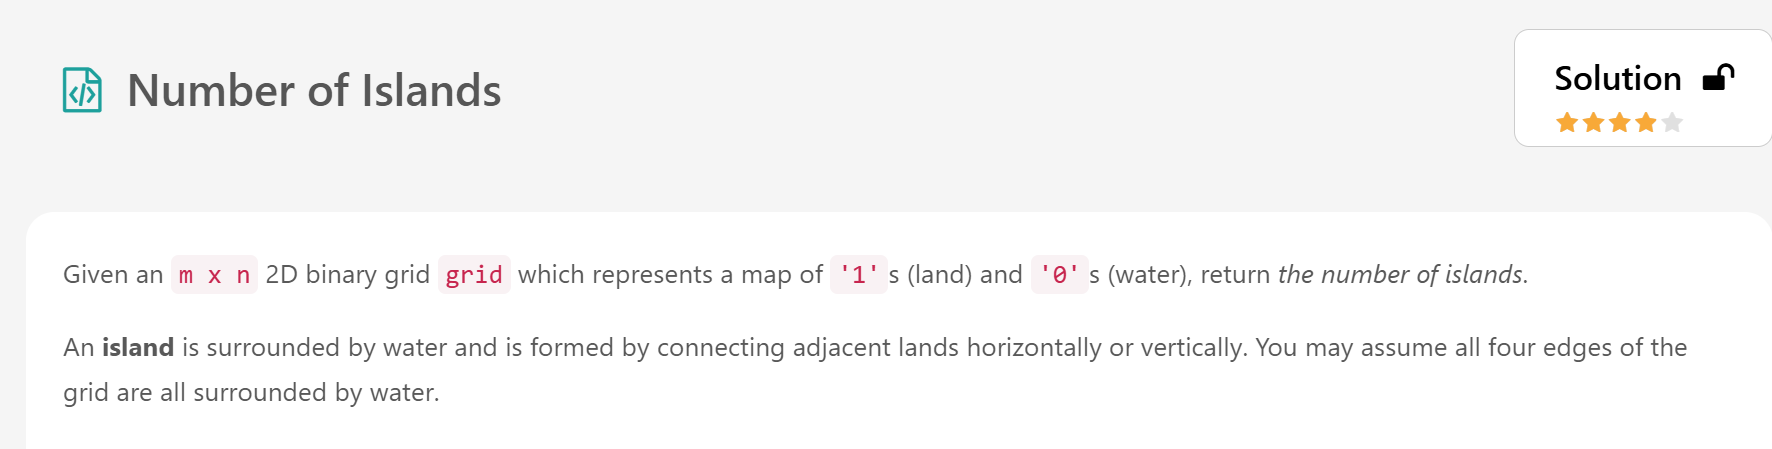

In [10]:
class Solution:
    def numIslands(self, grid: List[List[str]]) -> int:
        m, n = len(grid), len(grid[0])
        nums = 0
        visited = set()
        directions = [1,0,-1,0,1]
        
        for i in range(m):
            for j in range(n):
                
                if grid[i][j] == "1":
                    queue = deque([(i,j)])
                    visited.add((i,j))
                    nums += 1

                    while queue:
                        size = len(queue)
                        for _ in range(size):
                            cur_i, cur_j = queue.popleft()

                            for ind in range(4):
                                next_i = cur_i + directions[ind]
                                next_j = cur_j + directions[ind+1]
                                if 0 <= next_i < m and 0 <= next_j < n:
                                    if grid[next_i][next_j] == "1" and (next_i,next_j) not in visited:
                                        grid[next_i][next_j] = "0"
                                        visited.add((next_i,next_j))
                                        queue.append((next_i,next_j))
                        
                
        return nums

## Walls and Gates

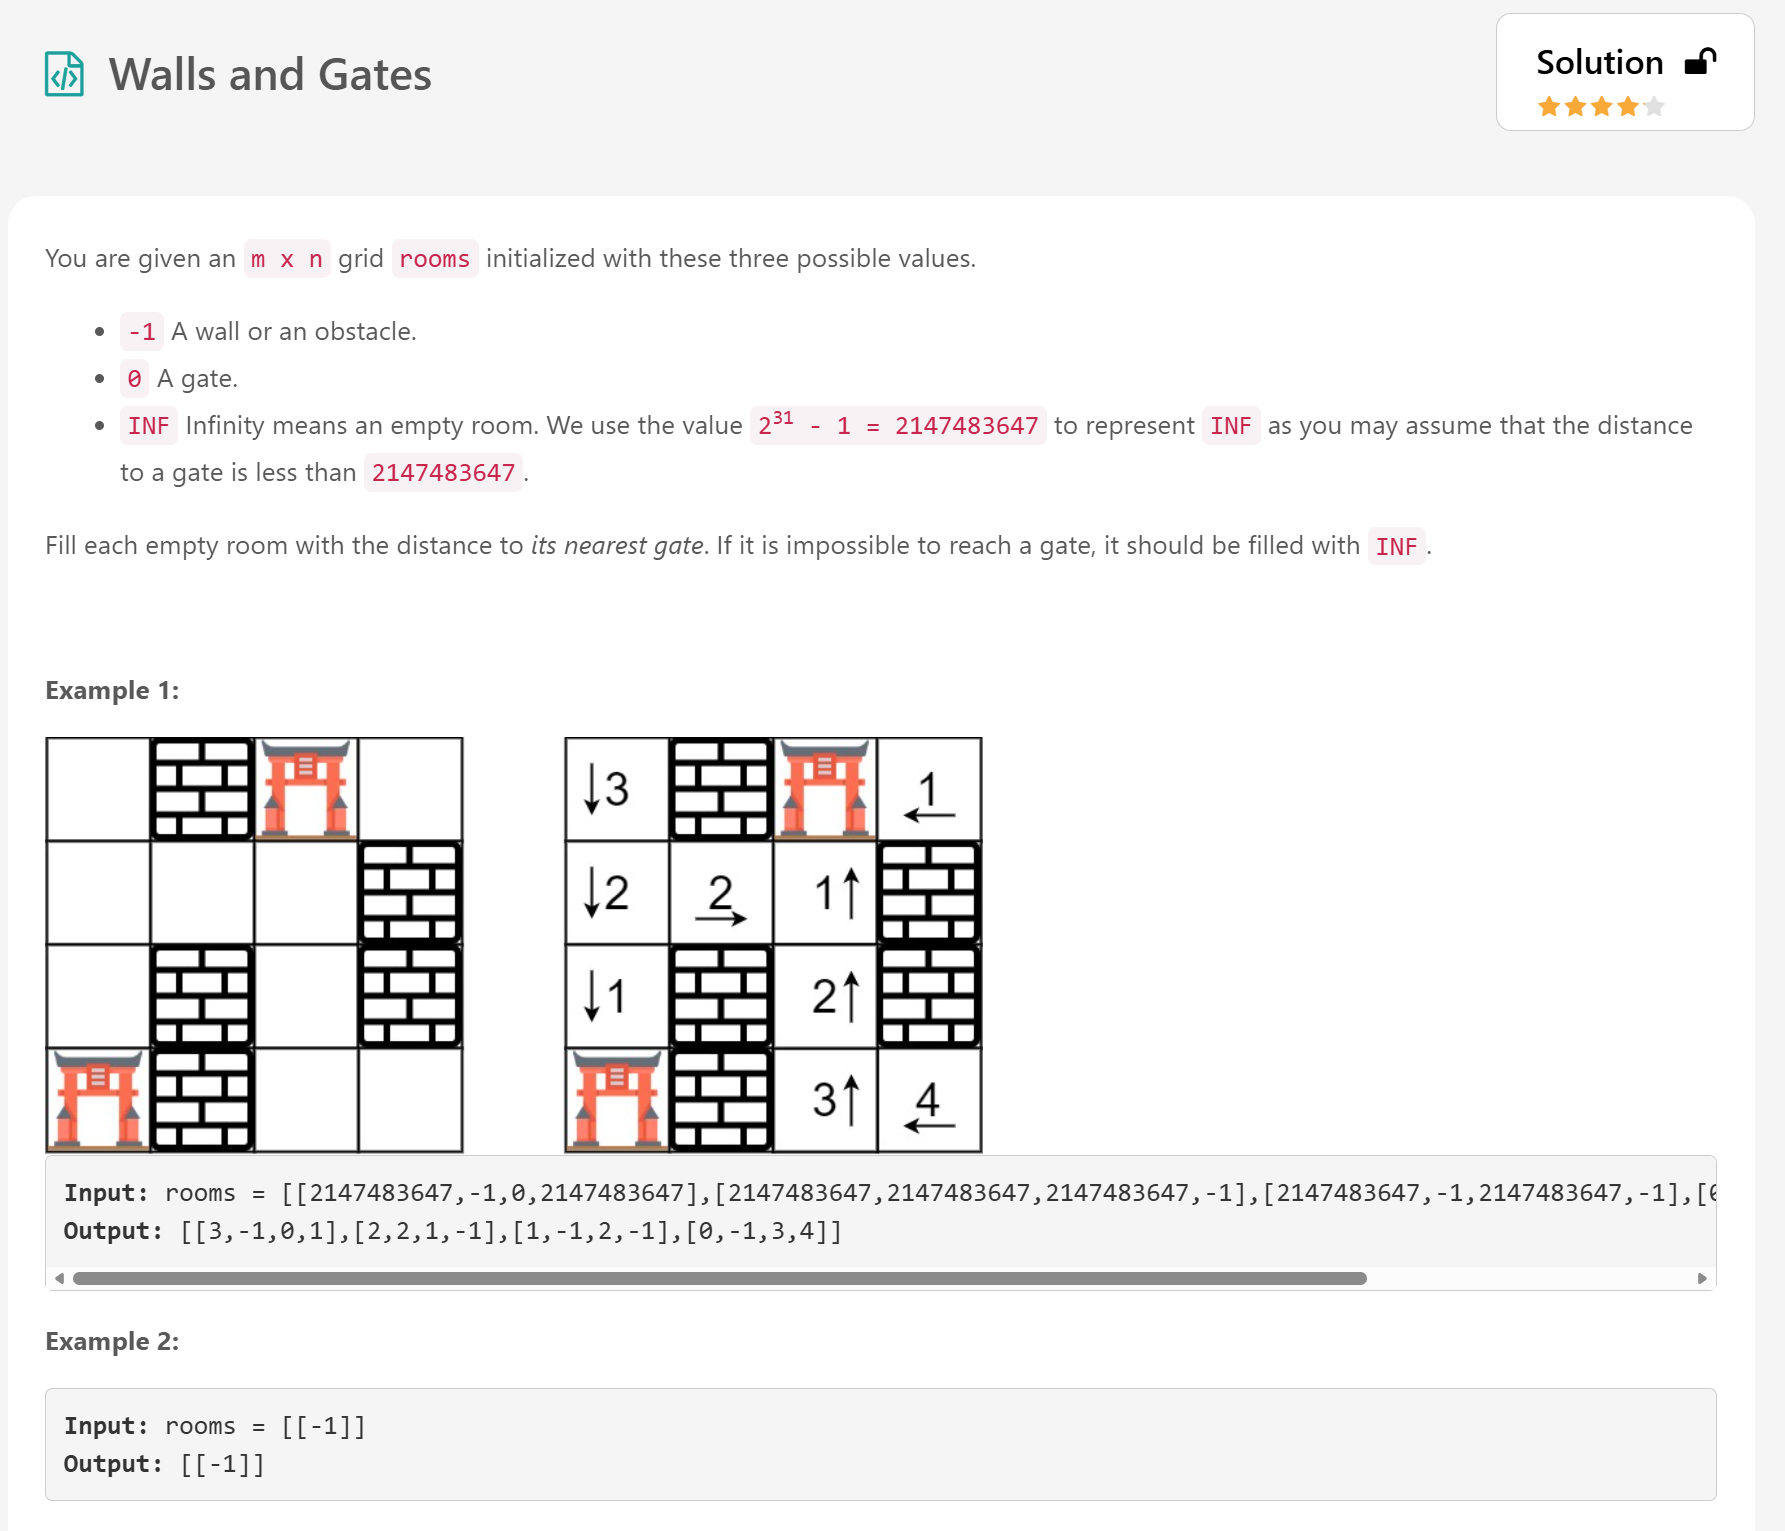

In [11]:
class Solution:
    def wallsAndGates(self, rooms: List[List[int]]) -> None:
        """
        Do not return anything, modify rooms in-place instead.
        """
        m, n = len(rooms), len(rooms[0])
        directions = [1,0,-1,0,1]
        for i in range(m):
            for j in range(n):
                if rooms[i][j] == 0:
                    queue = deque([(i,j)])
                    visited = set([(i,j)])
                    step = 0
                    
                    while queue:
                        size = len(queue)
                        
                        for _ in range(size):
                            cur_i, cur_j = queue.popleft()
                            
                            if rooms[cur_i][cur_j] >= 0:
                                rooms[cur_i][cur_j] = min(rooms[cur_i][cur_j],step)
                                
                                for idx in range(4):
                                    next_i, next_j = cur_i + directions[idx], cur_j + directions[idx+1]
                                    if (next_i,next_j)  not in visited:
                                        if 0 <= next_i < m and 0 <= next_j < n and rooms[next_i][next_j] > 0:
                                            visited.add((next_i,next_j))
                                            queue.append((next_i,next_j))
                                    
                        step += 1
                        
        return 
                        
                                
                    
        